<a href="https://colab.research.google.com/github/fralfaro/MAT281/blob/main/docs/lectures/machine_learning/mle_over.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# Overfitting de Modelos

<img src="https://msmk.university/wp-content/uploads/2025/06/Overfitting.png" width = "700" align="center"/>

<br>

> Construir un modelo que funcione bien en los datos de entrenamiento es fácil. El verdadero desafío es construir uno que **generalice** a datos nuevos. Este notebook cubre el problema del overfitting, las herramientas para detectarlo, y las estrategias para controlarlo.



## Librerías

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    KFold, learning_curve, validation_curve
)
from sklearn.metrics import mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

np.random.seed(42)

---

## 1. El Problema: Generalización

El objetivo de un modelo de Machine Learning no es memorizar los datos de entrenamiento, sino **aprender patrones que se mantengan en datos nuevos**. Cuando un modelo falla en este objetivo, decimos que no generaliza.

Existen dos formas opuestas de fallar:

| Problema | Descripción | Síntoma |
|---|---|---|
| **Underfitting** | El modelo es demasiado simple para capturar el patrón | Error alto en train **y** en test |
| **Overfitting** | El modelo memoriza el ruido del train set | Error bajo en train, error alto en test |

El objetivo es encontrar el punto intermedio: un modelo lo suficientemente complejo para capturar el patrón real, pero no tanto como para memorizar el ruido.

<!-- IMAGEN SUGERIDA: tres gráficos de dispersión con curvas ajustadas mostrando underfitting (línea recta), ajuste correcto (curva suave), y overfitting (curva que pasa exactamente por todos los puntos). -->

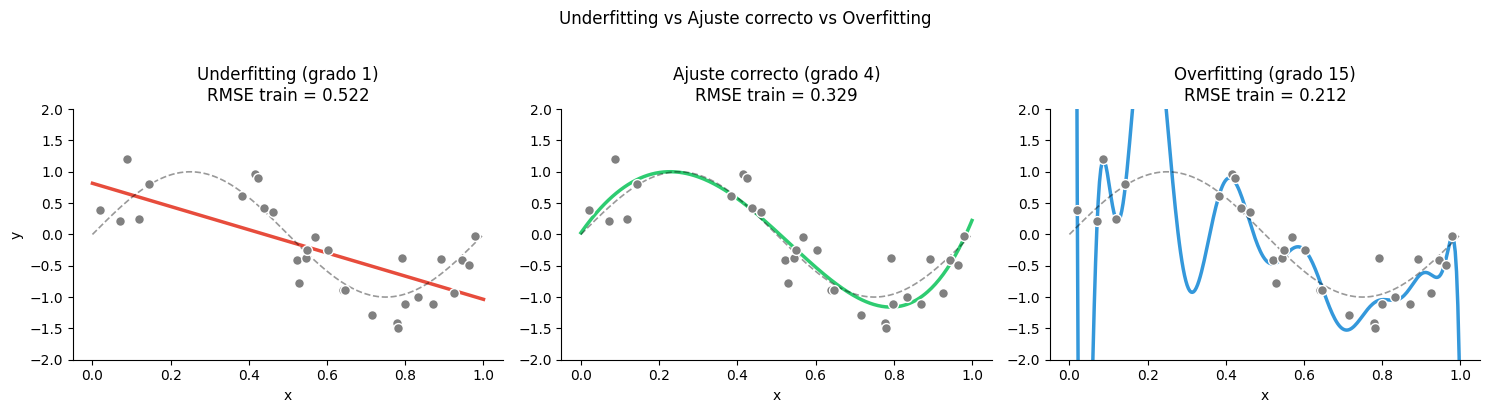

In [6]:
np.random.seed(0)
n = 30
X_demo = np.sort(np.random.uniform(0, 1, n))
y_demo = np.sin(2 * np.pi * X_demo) + np.random.normal(0, 0.3, n)

X_plot = np.linspace(0, 1, 300).reshape(-1, 1)
grados  = [1, 4, 15]
titulos = ["Underfitting (grado 1)", "Ajuste correcto (grado 4)", "Overfitting (grado 15)"]
colores = ["#e74c3c", "#2ecc71", "#3498db"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, grado, titulo, color in zip(axes, grados, titulos, colores):
    modelo = Pipeline([
        ("poly",   PolynomialFeatures(degree=grado)),
        ("scaler", StandardScaler()),
        ("lr",     LinearRegression())
    ])
    modelo.fit(X_demo.reshape(-1, 1), y_demo)
    y_plot       = modelo.predict(X_plot)
    y_pred_train = modelo.predict(X_demo.reshape(-1, 1))
    rmse_train   = mean_squared_error(y_demo, y_pred_train) ** 0.5  # ← corregido

    ax.scatter(X_demo, y_demo, color="gray", edgecolor="white", s=50, zorder=5)
    ax.plot(X_plot, y_plot, color=color, lw=2.5)
    ax.plot(X_plot, np.sin(2 * np.pi * X_plot), "k--", lw=1.2, alpha=0.4, label="Patrón real")
    ax.set_title(f"{titulo}\nRMSE train = {rmse_train:.3f}")
    ax.set_ylim(-2, 2)
    ax.set_xlabel("x")

axes[0].set_ylabel("y")
plt.suptitle("Underfitting vs Ajuste correcto vs Overfitting", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

---

## 2. Bias-Variance Tradeoff

El error de generalización de cualquier modelo se puede descomponer en tres partes:

$$\text{Error} = \text{Bias}^2 + \text{Varianza} + \text{Ruido irreducible}$$

| Componente | Descripción | Causa |
|---|---|---|
| **Bias (sesgo)** | El modelo sistemáticamente no captura el patrón real | Modelo demasiado simple |
| **Varianza** | Las predicciones cambian mucho según los datos de entrenamiento | Modelo demasiado complejo |
| **Ruido** | Variabilidad intrínseca de los datos | No controlable |

Aumentar la complejidad del modelo **reduce el bias pero aumenta la varianza**. El arte está en encontrar el balance óptimo.

<!-- IMAGEN SUGERIDA: gráfico clásico de bias-variance tradeoff con el eje X de complejidad del modelo, la curva U de error total, y las curvas de bias² (decreciente) y varianza (creciente). -->

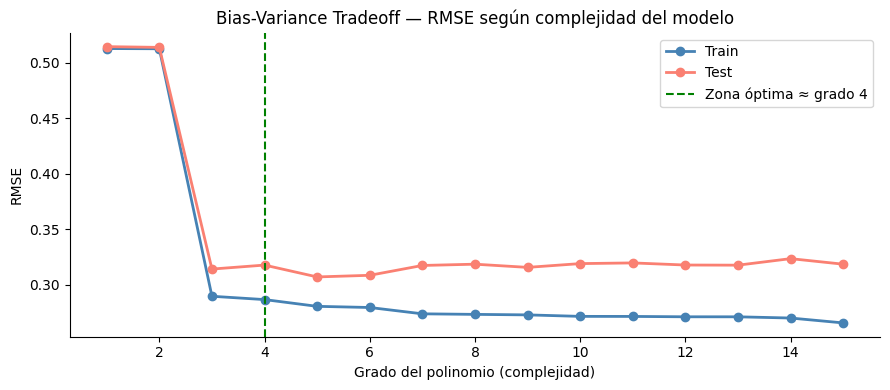

→ Train sigue bajando siempre (el modelo memoriza)
→ Test baja hasta el óptimo y luego sube (overfitting)


In [8]:
np.random.seed(42)
n_total = 200
X_bv = np.sort(np.random.uniform(0, 1, n_total)).reshape(-1, 1)
y_bv = np.sin(2 * np.pi * X_bv.ravel()) + np.random.normal(0, 0.3, n_total)
X_tr, X_te, y_tr, y_te = train_test_split(X_bv, y_bv, test_size=0.3, random_state=42)

grados = range(1, 16)
rmse_train_list, rmse_test_list = [], []

for g in grados:
    m = Pipeline([
        ("poly",   PolynomialFeatures(degree=g)),
        ("scaler", StandardScaler()),
        ("lr",     LinearRegression())
    ])
    m.fit(X_tr, y_tr)
    rmse_train_list.append(mean_squared_error(y_tr, m.predict(X_tr)) ** 0.5)  # ← corregido
    rmse_test_list.append(mean_squared_error(y_te, m.predict(X_te)) ** 0.5)   # ← corregido

fig, ax = plt.subplots()
ax.plot(grados, rmse_train_list, "o-", color="steelblue", lw=2, ms=6, label="Train")
ax.plot(grados, rmse_test_list,  "o-", color="salmon",    lw=2, ms=6, label="Test")
ax.axvline(4, color="green", lw=1.5, linestyle="--", label="Zona óptima ≈ grado 4")
ax.set_title("Bias-Variance Tradeoff — RMSE según complejidad del modelo")
ax.set_xlabel("Grado del polinomio (complejidad)")
ax.set_ylabel("RMSE")
ax.legend()
plt.tight_layout()
plt.show()

print("→ Train sigue bajando siempre (el modelo memoriza)")
print("→ Test baja hasta el óptimo y luego sube (overfitting)")

---

## 3. Train/Test Split: El Primer Escudo

La separación entre datos de entrenamiento y datos de prueba es la protección más básica contra el overfitting. La regla fundamental es:

> **El modelo nunca debe ver el test set durante el entrenamiento ni durante ninguna decisión de diseño del modelo.**

Violaciones frecuentes de esta regla:

| Violación | Consecuencia |
|---|---|
| Escalar con `fit` sobre todo el dataset (train+test) | Data leakage: el test "contamina" la normalización |
| Seleccionar features mirando la correlación con todo el dataset | El modelo se ajusta a patrones del test sin saberlo |
| Elegir hiperparámetros evaluando directamente en test | El test set se convierte en set de validación |
| Iterar el modelo hasta que funciona bien en test | El test ya no mide generalización |

<!-- IMAGEN SUGERIDA: diagrama de tres bloques train/validation/test, mostrando que train se usa para fit, validation para tuning, y test solo al final para reporte. -->

In [9]:
# Dataset para los ejemplos siguientes: predicción de precio de viviendas
np.random.seed(42)
n = 500
superficie   = np.random.uniform(40, 220, n)
habitaciones = np.random.randint(1, 6, n).astype(float)
distancia    = np.random.uniform(1, 35, n)
antiguedad   = np.random.uniform(0, 45, n)

precio = (2_000_000
          + 38_000  * superficie
          + 900_000 * habitaciones
          - 130_000 * distancia
          - 55_000  * antiguedad
          + np.random.normal(0, 2_500_000, n))

df = pd.DataFrame({
    'precio': precio, 'superficie': superficie,
    'habitaciones': habitaciones, 'distancia': distancia,
    'antiguedad': antiguedad
})

X = df.drop(columns='precio')
y = df['precio']

# Split correcto: escalar SOLO sobre train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ✅ Correcto: fit_transform en train, transform en test
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)          # solo transform, no fit

print("✅ Pipeline correcto: scaler ajustado solo sobre train")
print(f"   Train media superficie: {scaler.mean_[0]:.1f}  (calculada solo en train)")

✅ Pipeline correcto: scaler ajustado solo sobre train
   Train media superficie: 130.7  (calculada solo en train)


---

## 4. Validación Cruzada (Cross-Validation)

El split simple train/test tiene un problema: el resultado depende de cómo se hizo la división. Con mala suerte, el test set puede ser atípico.

La **validación cruzada k-fold** soluciona esto dividiendo los datos en $k$ partes (*folds*) y repitiendo el proceso $k$ veces: en cada iteración, uno de los folds es el set de validación y los $k-1$ restantes son el set de entrenamiento. El rendimiento final es el promedio de las $k$ iteraciones.

**Ventajas:**
- Estimación más estable del rendimiento real
- Usa todos los datos tanto para entrenar como para evaluar
- Permite detectar si el rendimiento varía mucho entre folds (señal de inestabilidad)

**Valor de $k$ típico:** 5 o 10. Mayor $k$ → estimación más precisa pero más lento.

<!-- IMAGEN SUGERIDA: diagrama de 5-fold CV mostrando las 5 iteraciones, con el fold de validación resaltado en cada una y la flecha de promedio al final. -->

In [10]:
# Comparación: split único vs cross-validation
modelos = {
    'Árbol (depth=3)':  DecisionTreeRegressor(max_depth=3,  random_state=42),
    'Árbol (depth=10)': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest':    RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
}

print(f"{'Modelo':<22} {'R² train':>10} {'R² test':>10} {'R² CV (5-fold)':>15} {'CV std':>8}")
print("-" * 68)

for nombre, m in modelos.items():
    m.fit(X_train, y_train)
    r2_tr = r2_score(y_train, m.predict(X_train))
    r2_te = r2_score(y_test,  m.predict(X_test))
    scores_cv = cross_val_score(m, X, y, cv=5, scoring='r2', n_jobs=-1)
    print(f"{nombre:<22} {r2_tr:>10.4f} {r2_te:>10.4f} "
          f"{scores_cv.mean():>15.4f} {scores_cv.std():>8.4f}")

Modelo                   R² train    R² test  R² CV (5-fold)   CV std
--------------------------------------------------------------------
Árbol (depth=3)            0.4879     0.2876          0.3563   0.0572
Árbol (depth=10)           0.9656    -0.3676         -0.0881   0.0217
Random Forest              0.9197     0.3247          0.4124   0.0333


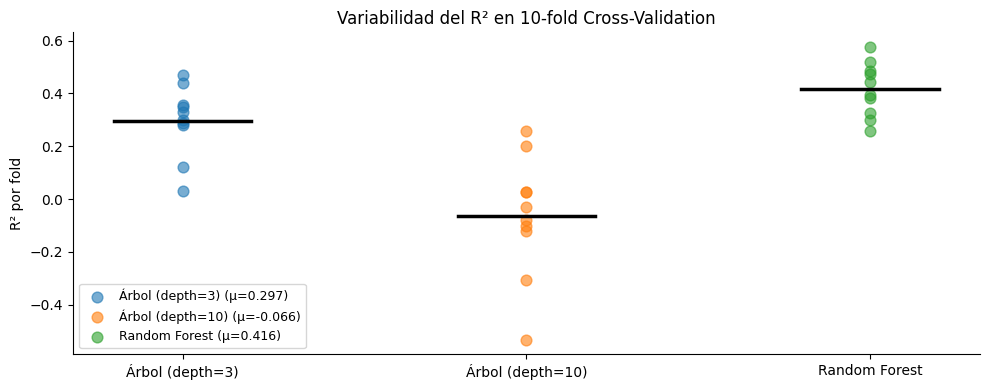

In [11]:
# Visualización: distribución de R² por fold
fig, ax = plt.subplots(figsize=(10, 4))
kf = KFold(n_splits=10, shuffle=True, random_state=42)

for i, (nombre, m) in enumerate(modelos.items()):
    scores = cross_val_score(m, X, y, cv=kf, scoring='r2', n_jobs=-1)
    ax.scatter([i]*len(scores), scores, alpha=0.6, s=60,
               label=f'{nombre} (μ={scores.mean():.3f})')
    ax.plot([i-0.2, i+0.2], [scores.mean()]*2, 'k-', lw=2.5)

ax.set_xticks(range(len(modelos)))
ax.set_xticklabels(list(modelos.keys()))
ax.set_ylabel('R² por fold')
ax.set_title('Variabilidad del R² en 10-fold Cross-Validation')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---

## 5. Curvas de Aprendizaje

Una **curva de aprendizaje** muestra cómo evoluciona el rendimiento del modelo en función del **tamaño del dataset**. Es una herramienta diagnóstica poderosa:

| Patrón | Diagnóstico | Solución |
|---|---|---|
| Train y test convergen en error alto | Underfitting / alto bias | Modelo más complejo |
| Train bajo, test alto, brecha no cierra | Overfitting / alta varianza | Más datos o regularización |
| Train y test convergen en error bajo | Buen modelo | Agregar más datos ayuda poco |
| Test mejora al agregar datos | El modelo se beneficia de más datos | Conseguir más datos |

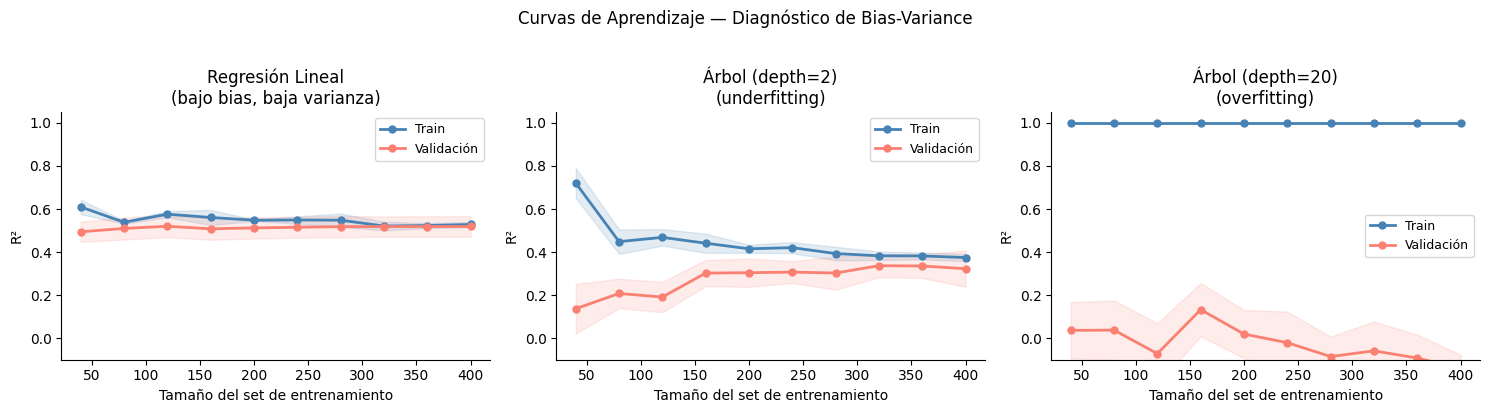

In [12]:
def plot_learning_curve(modelo, X, y, titulo, ax, cv=5):
    train_sizes, train_scores, test_scores = learning_curve(
        modelo, X, y,
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=cv, scoring='r2', n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    test_mean  = test_scores.mean(axis=1)
    test_std   = test_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color='steelblue', lw=2, ms=5, label='Train')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                    alpha=0.15, color='steelblue')
    ax.plot(train_sizes, test_mean, 'o-', color='salmon', lw=2, ms=5, label='Validación')
    ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std,
                    alpha=0.15, color='salmon')
    ax.set_title(titulo)
    ax.set_xlabel('Tamaño del set de entrenamiento')
    ax.set_ylabel('R²')
    ax.legend(fontsize=9)
    ax.set_ylim(-0.1, 1.05)


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_learning_curve(
    LinearRegression(), X, y,
    'Regresión Lineal\n(bajo bias, baja varianza)', axes[0]
)
plot_learning_curve(
    DecisionTreeRegressor(max_depth=2, random_state=42), X, y,
    'Árbol (depth=2)\n(underfitting)', axes[1]
)
plot_learning_curve(
    DecisionTreeRegressor(max_depth=20, random_state=42), X, y,
    'Árbol (depth=20)\n(overfitting)', axes[2]
)

plt.suptitle('Curvas de Aprendizaje — Diagnóstico de Bias-Variance', y=1.02)
plt.tight_layout()
plt.show()

---

## 6. Curvas de Validación

Una **curva de validación** muestra cómo varía el rendimiento al cambiar un **hiperparámetro específico**. Complementa la curva de aprendizaje: en lugar de variar el tamaño del dataset, variamos la complejidad del modelo.

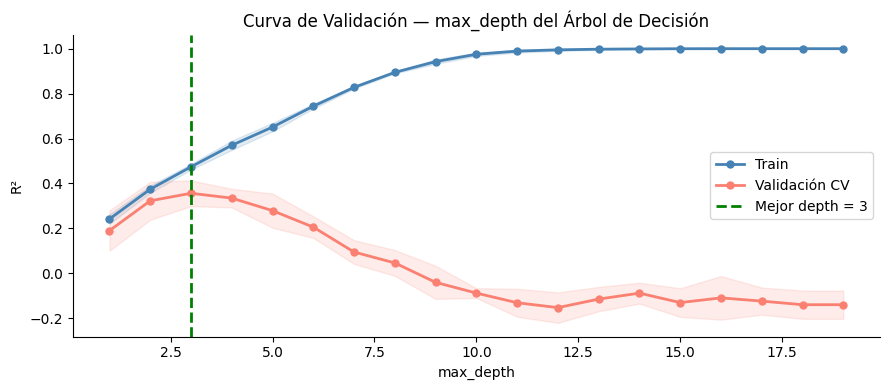

Mejor max_depth según CV: 3
R² validación en ese punto: 0.3563


In [13]:
# Curva de validación: max_depth del árbol
param_range = range(1, 20)
train_scores, test_scores = validation_curve(
    DecisionTreeRegressor(random_state=42),
    X, y,
    param_name='max_depth',
    param_range=param_range,
    cv=5, scoring='r2', n_jobs=-1
)

fig, ax = plt.subplots()
ax.plot(param_range, train_scores.mean(axis=1), 'o-',
        color='steelblue', lw=2, ms=5, label='Train')
ax.fill_between(param_range,
                train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1),
                alpha=0.15, color='steelblue')
ax.plot(param_range, test_scores.mean(axis=1), 'o-',
        color='salmon', lw=2, ms=5, label='Validación CV')
ax.fill_between(param_range,
                test_scores.mean(axis=1) - test_scores.std(axis=1),
                test_scores.mean(axis=1) + test_scores.std(axis=1),
                alpha=0.15, color='salmon')

mejor_depth = param_range[np.argmax(test_scores.mean(axis=1))]
ax.axvline(mejor_depth, color='green', lw=2, linestyle='--',
           label=f'Mejor depth = {mejor_depth}')
ax.set_title('Curva de Validación — max_depth del Árbol de Decisión')
ax.set_xlabel('max_depth')
ax.set_ylabel('R²')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mejor max_depth según CV: {mejor_depth}")
print(f"R² validación en ese punto: {test_scores.mean(axis=1)[mejor_depth-1]:.4f}")

---

## 7. Estrategias para Controlar el Overfitting

### 7.1 Regularización

Ya vista en el notebook de regresión: Ridge y Lasso penalizan coeficientes grandes, reduciendo la varianza del modelo. La curva de validación del hiperparámetro `alpha` permite elegir el nivel de regularización óptimo.

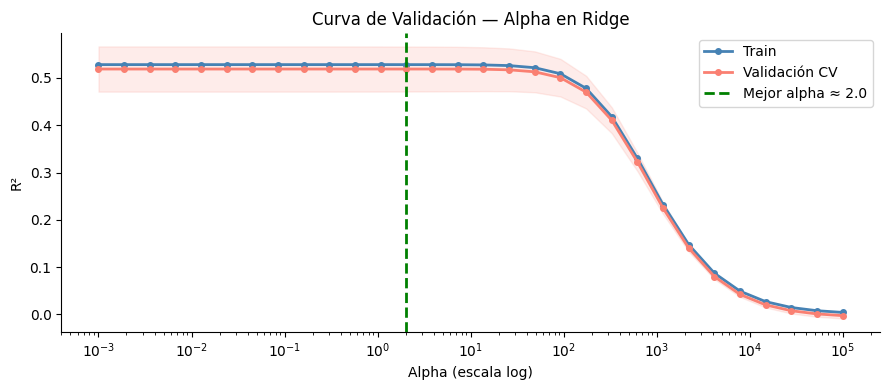

In [14]:
# Curva de validación para alpha en Ridge
alphas = np.logspace(-3, 5, 30)

ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge',  Ridge())
])

train_scores_r, test_scores_r = validation_curve(
    ridge_pipe, X, y,
    param_name='ridge__alpha',
    param_range=alphas,
    cv=5, scoring='r2', n_jobs=-1
)

fig, ax = plt.subplots()
ax.semilogx(alphas, train_scores_r.mean(axis=1), 'o-',
            color='steelblue', lw=2, ms=4, label='Train')
ax.semilogx(alphas, test_scores_r.mean(axis=1), 'o-',
            color='salmon', lw=2, ms=4, label='Validación CV')
ax.fill_between(alphas,
                test_scores_r.mean(axis=1) - test_scores_r.std(axis=1),
                test_scores_r.mean(axis=1) + test_scores_r.std(axis=1),
                alpha=0.15, color='salmon')
mejor_alpha = alphas[np.argmax(test_scores_r.mean(axis=1))]
ax.axvline(mejor_alpha, color='green', lw=2, linestyle='--',
           label=f'Mejor alpha ≈ {mejor_alpha:.1f}')
ax.set_title('Curva de Validación — Alpha en Ridge')
ax.set_xlabel('Alpha (escala log)')
ax.set_ylabel('R²')
ax.legend()
plt.tight_layout()
plt.show()

### 7.2 Más datos

El overfitting por varianza se reduce con más datos de entrenamiento. La curva de aprendizaje indica si el modelo se beneficiaría de un dataset más grande.

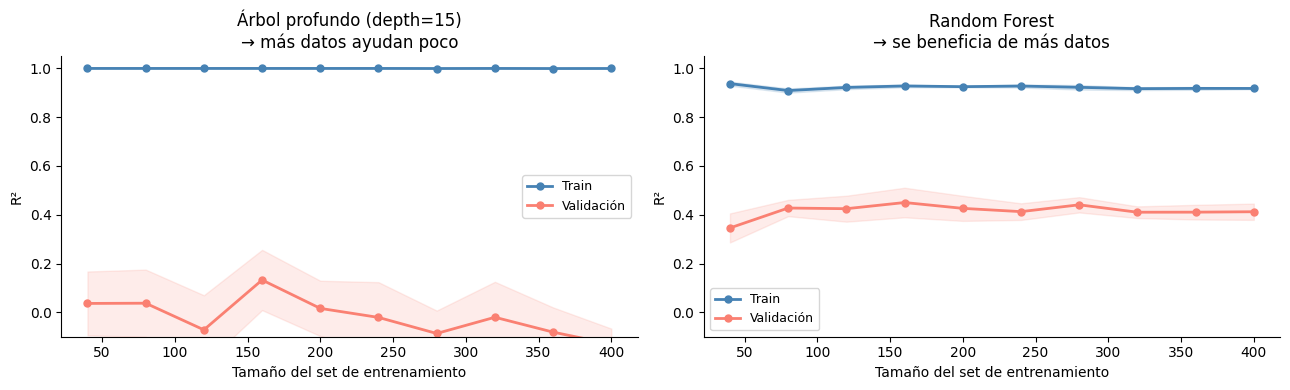

In [15]:
# ¿Sirve agregar más datos? Comparamos árbol profundo vs Random Forest
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

plot_learning_curve(
    DecisionTreeRegressor(max_depth=15, random_state=42), X, y,
    'Árbol profundo (depth=15)\n→ más datos ayudan poco', axes[0]
)
plot_learning_curve(
    RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1), X, y,
    'Random Forest\n→ se beneficia de más datos', axes[1]
)
plt.tight_layout()
plt.show()

### 7.3 Resumen de estrategias

| Estrategia | Reduce | Cuándo usarla |
|---|---|---|
| Modelo más simple | Varianza | Test mucho peor que train |
| Regularización (Ridge/Lasso) | Varianza | Modelos lineales con muchas features |
| `max_depth` menor | Varianza | Árboles de decisión |
| `n_estimators` mayor | Varianza | Random Forest |
| Más datos de entrenamiento | Varianza | Si la curva de aprendizaje no convergió |
| Modelo más complejo | Bias | Train y test igualmente malos |
| Más features relevantes | Bias | El modelo no captura el patrón |

---

## 8. Flujo Correcto de Evaluación

Reunimos todo en el flujo recomendado para evaluar y seleccionar modelos de forma rigurosa.

In [16]:
# ============================================================
# FLUJO CORRECTO
# 1. Split train / test ANTES de cualquier decisión
# 2. Usar CV sobre train para comparar modelos y elegir hiperparámetros
# 3. Reportar rendimiento final UNA SOLA VEZ sobre test
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

candidatos = {
    'Regresión Lineal':  LinearRegression(),
    'Ridge (α=100)':     Pipeline([('s', StandardScaler()), ('m', Ridge(alpha=100))]),
    'Árbol (depth=5)':   DecisionTreeRegressor(max_depth=5,  random_state=42),
    'Árbol (depth=15)':  DecisionTreeRegressor(max_depth=15, random_state=42),
    'Random Forest':     RandomForestRegressor(n_estimators=200, max_depth=8,
                                               random_state=42, n_jobs=-1),
}

print("=== PASO 1: Comparación por CV sobre train ===")
print(f"{'Modelo':<22} {'R² CV (media)':>14} {'CV std':>8}")
print("-" * 46)

mejor_modelo_nombre = None
mejor_score_cv      = -np.inf

for nombre, m in candidatos.items():
    scores = cross_val_score(m, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
    print(f"{nombre:<22} {scores.mean():>14.4f} {scores.std():>8.4f}")
    if scores.mean() > mejor_score_cv:
        mejor_score_cv      = scores.mean()
        mejor_modelo_nombre = nombre

print(f"\n→ Mejor modelo según CV: {mejor_modelo_nombre} (R² = {mejor_score_cv:.4f})")

=== PASO 1: Comparación por CV sobre train ===
Modelo                  R² CV (media)   CV std
----------------------------------------------
Regresión Lineal               0.5213   0.0573
Ridge (α=100)                  0.4943   0.0449
Árbol (depth=5)                0.3153   0.0806
Árbol (depth=15)               0.0752   0.1342
Random Forest                  0.4500   0.0603

→ Mejor modelo según CV: Regresión Lineal (R² = 0.5213)


In [17]:
# PASO 2: Entrenamos el mejor modelo sobre TODO train
# PASO 3: Evaluamos UNA SOLA VEZ sobre test

mejor_modelo = candidatos[mejor_modelo_nombre]
mejor_modelo.fit(X_train, y_train)
r2_final = r2_score(y_test, mejor_modelo.predict(X_test))

print("=== PASO 2-3: Evaluación final sobre test ===")
print(f"Modelo: {mejor_modelo_nombre}")
print(f"R² en test (reporte final): {r2_final:.4f}")
print()
print("⚠️  Este número se reporta UNA SOLA VEZ.")
print("   Si lo usamos para seguir ajustando el modelo, pierde su validez.")

=== PASO 2-3: Evaluación final sobre test ===
Modelo: Regresión Lineal
R² en test (reporte final): 0.4319

⚠️  Este número se reporta UNA SOLA VEZ.
   Si lo usamos para seguir ajustando el modelo, pierde su validez.


---

## Resumen

| Concepto | Idea central |
|---|---|
| **Overfitting** | El modelo memoriza el ruido del train set y no generaliza |
| **Underfitting** | El modelo es demasiado simple para capturar el patrón |
| **Bias** | Error sistemático por modelo demasiado simple |
| **Varianza** | Sensibilidad a los datos de entrenamiento por modelo demasiado complejo |
| **Train/Test split** | Separación obligatoria; el test nunca debe influir en el diseño |
| **Cross-validation** | Estimación más estable del rendimiento real usando todos los datos |
| **Curva de aprendizaje** | Diagnostica bias vs varianza en función del tamaño del dataset |
| **Curva de validación** | Diagnostica el efecto de un hiperparámetro sobre train vs test |
| **Regularización** | Penaliza coeficientes grandes para reducir varianza |
| **Flujo correcto** | CV sobre train para elegir modelo → evaluar test una sola vez al final |

---

## Referencias

1. James, G., Witten, D., Hastie, T., Tibshirani, R. (2021). *An Introduction to Statistical Learning*. Springer. Cap. 5 y 6.
2. Scikit-learn — Model selection: [https://scikit-learn.org/stable/model_selection.html](https://scikit-learn.org/stable/model_selection.html)
3. Scikit-learn — `learning_curve`: [https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.learning_curve.html](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.learning_curve.html)